In [ ]:
# Loan Eligibility Prediction
# Internship Task - HexSoftwares
# Name:Anam kondvilkar

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from IPython.display import display, HTML

display(HTML("<h1 style='color:#2E86C1;'>📊 DATASET OVERVIEW</h1>"))

display(HTML("<h3>📌 Dataset Shape</h3>"))
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")

display(HTML("<h3>📌 Missing Values</h3>"))
missing = df.isnull().sum().reset_index()
missing.columns = ['Feature', 'Missing Values']
missing = missing[missing['Missing Values'] > 0]
display(missing)

display(HTML("<h3>📌 Data Types</h3>"))
dtypes = df.dtypes.reset_index()
dtypes.columns = ['Feature', 'Data Type']
display(dtypes)

display(HTML("<h3>📌 Statistical Summary</h3>"))
summary = df.describe().T[['mean', 'std', 'min', 'max']]
summary = summary.round(2)
display(summary)

Rows: 614 | Columns: 13


,Feature,Missing Values
1,Gender,13
2,Married,3
3,Dependents,15
5,Self_Employed,32
8,LoanAmount,22
9,Loan_Amount_Term,14
10,Credit_History,50


,Feature,Data Type
0,Loan_ID,object
1,Gender,object
2,Married,object
3,Dependents,object
4,Education,object
5,Self_Employed,object
6,ApplicantIncome,int64
7,CoapplicantIncome,float64
8,LoanAmount,float64
9,Loan_Amount_Term,float64


,mean,std,min,max
ApplicantIncome,5403.46,6109.04,150.0,81000.0
CoapplicantIncome,1621.25,2926.25,0.0,41667.0
LoanAmount,146.41,85.59,9.0,700.0
Loan_Amount_Term,342.00,65.12,12.0,480.0
Credit_History,0.84,0.36,0.0,1.0


"The dataset shows variation in applicant income, loan amount, and loan term. Mean and standard deviation indicate distribution of numeric features."

In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

for col in ['Gender','Married','Dependents','Self_Employed']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:
df.drop('Loan_ID', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:

df['Loan_Status'] = df['Loan_Status'].astype(str)

df['Loan_Status_Label'] = df['Loan_Status'].apply(lambda x:
    'Approved' if x in ['1', 'Y', 'Yes', 'Approved'] else 'Not Approved'
)

print(df['Loan_Status_Label'].value_counts())

Loan_Status_Label
Approved        422
Not Approved    192
Name: count, dtype: int64


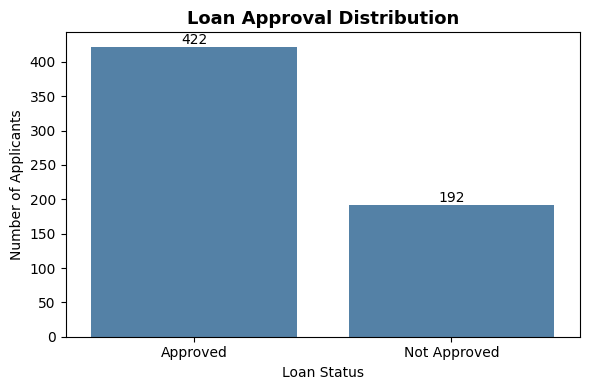

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(x='Loan_Status_Label', data=df, color='steelblue')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Loan Approval Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

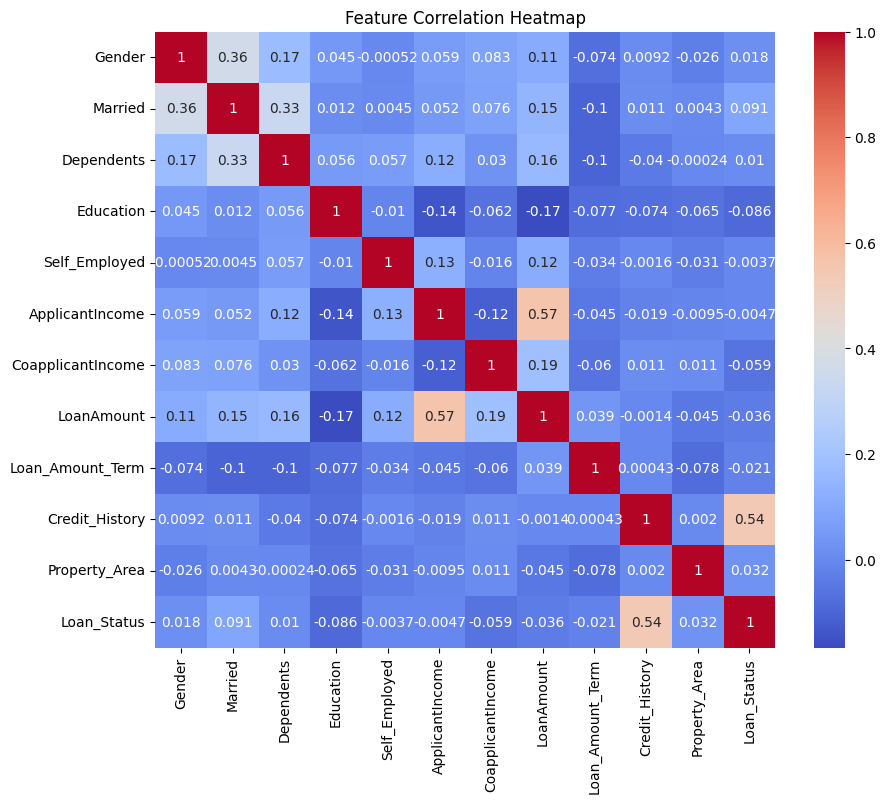

In [ ]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

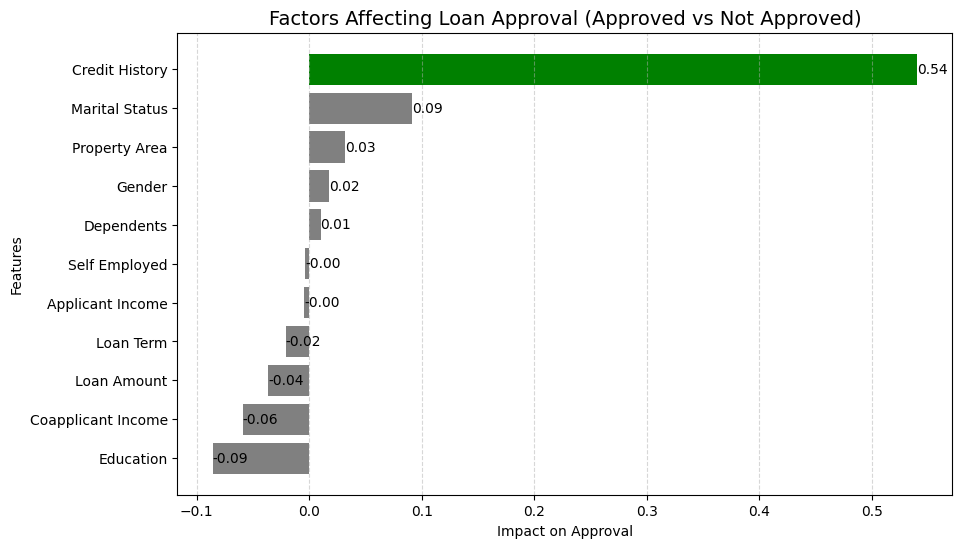

In [ ]:

df['Loan_Status_Label'] = df['Loan_Status'].map({0: 'Not Approved', 1: 'Approved'})

corr_target = numeric_df.corr()['Loan_Status'].drop('Loan_Status')
corr_target = corr_target.sort_values()

feature_names = {
    'Credit_History': 'Credit History',
    'ApplicantIncome': 'Applicant Income',
    'CoapplicantIncome': 'Coapplicant Income',
    'LoanAmount': 'Loan Amount',
    'Loan_Amount_Term': 'Loan Term',
    'Gender': 'Gender',
    'Married': 'Marital Status',
    'Dependents': 'Dependents',
    'Education': 'Education',
    'Self_Employed': 'Self Employed',
    'Property_Area': 'Property Area'
}

corr_target.index = [feature_names.get(i, i) for i in corr_target.index]

colors = ['green' if abs(val) > 0.3 else 'gray' for val in corr_target]

plt.figure(figsize=(10,6))

bars = plt.barh(corr_target.index, corr_target.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center')

plt.title("Factors Affecting Loan Approval (Approved vs Not Approved)", fontsize=14)
plt.xlabel("Impact on Approval")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['Loan_Status', 'Loan_Status_Label'], axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7723577235772358


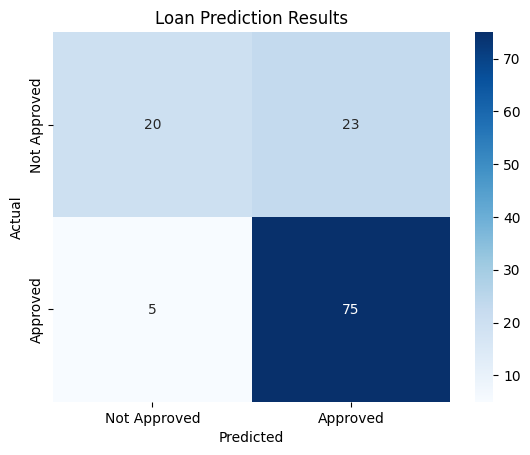

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])

plt.title("Loan Prediction Results")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
from sklearn.metrics import classification_report
from IPython.display import display, HTML
import pandas as pd

# Convert report to dictionary
report = classification_report(
    y_test,
    y_pred,
    target_names=['Not Approved', 'Approved'],
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose().round(2)

# Display title
display(HTML("<h2 style='color:#2E86C1;'>Model Performance Report</h2>"))

# Display styled table
display(report_df.style
        .background_gradient(cmap='Blues')
        .set_properties(**{'text-align': 'center'}))

,precision,recall,f1-score,support
Not Approved,0.800000,0.470000,0.590000,43.000000
Approved,0.770000,0.940000,0.840000,80.000000
accuracy,0.770000,0.770000,0.770000,0.770000
macro avg,0.780000,0.700000,0.720000,123.000000
weighted avg,0.780000,0.770000,0.750000,123.000000


The model achieved 77% accuracy. It performs better in predicting approved loans compared to not approved loans. Credit history was found to be the most important factor affecting loan approval.

In [ ]:
sample = X_test[0:1]
prediction = model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Loan Approved


In [66]:
from IPython.display import display, HTML

display(HTML("<h2 style='color:green;'>📌 Final Conclusion</h2>"))

print("""
1. Credit History is the most important factor.
2. Most loans are approved in dataset.
3. Logistic Regression achieved ~77% accuracy.
4. Model performs well for Approved cases.
5. Further improvement possible using advanced models.
""")


1. Credit History is the most important factor.
2. Most loans are approved in dataset.
3. Logistic Regression achieved ~77% accuracy.
4. Model performs well for Approved cases.
5. Further improvement possible using advanced models.

